In [12]:
exp_name = 'gmd_radiative_convective_1420w_10min_v3' #'64x32_4h_400w' 'gmd_radiative_convective_1420w_10min'
exp_folder_name = 'column_code_with_slab' # 'column_code_with_slab' 'gmd_aquaplanet' 'column_rrtmg' 'aquaplanet_RCE_single'
emulate = 'conv' # 'conv' 'rad'
model_name = 'lstm' # 'mlp_v2' 'lstm', 'trsfm'
online_path = f'/projects/sds-lab/Shuochen/climt/{exp_folder_name}/{exp_name}_{emulate}'
exp_name_online = '0'

import torch
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import optuna
import sys,os
sys.path.append("..")
import numpy as np
import random
import seaborn as sns
import xarray as xr

# conv-single-col

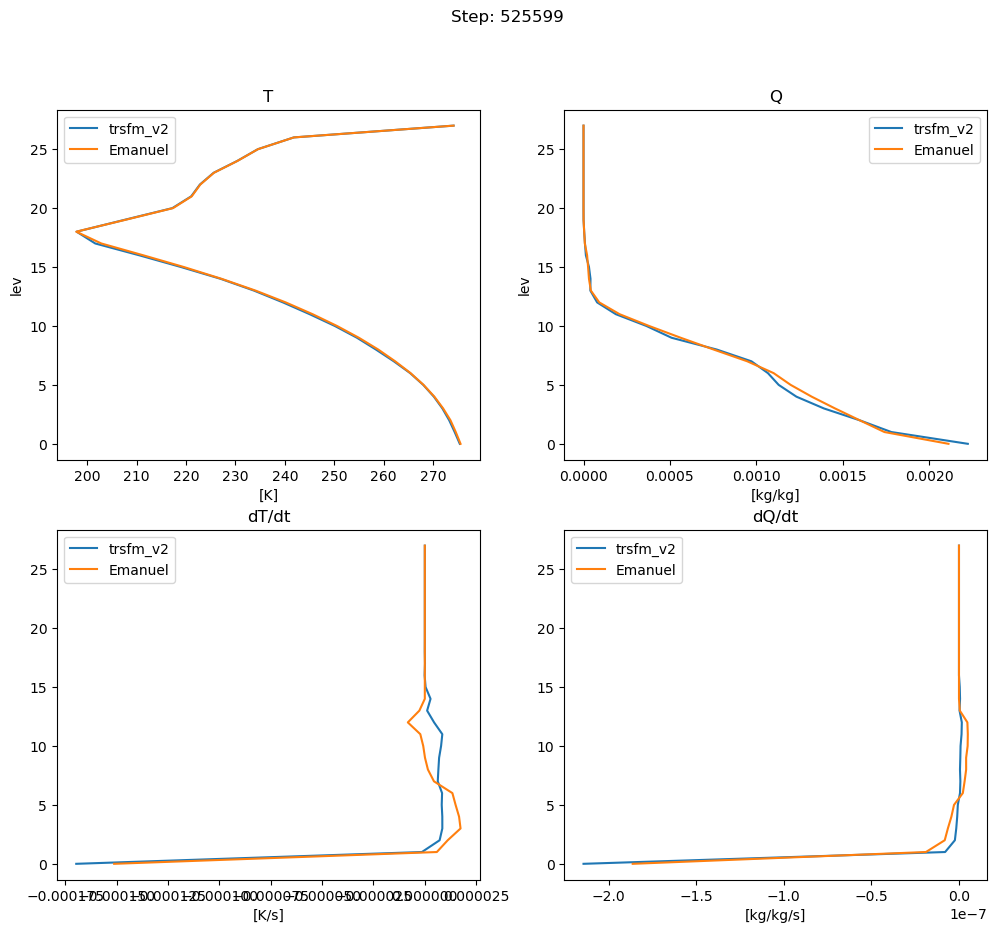

In [3]:
year = 10
time_idx = 52560 * year - 1
lev_idx = 0

nn_input = xr.open_dataset(online_path + f'/online_input_{model_name}_{exp_name_online}.nc')
nn_output = xr.open_dataset(online_path + f'/online_output_{model_name}_{exp_name_online}.nc')
physics_input = xr.open_dataset(online_path + f'/online_input_physics.nc')
physics_output = xr.open_dataset(online_path + f'/online_output_physics.nc')

fig = plt.figure(figsize=(12,10))
plt.suptitle(f'Step: {time_idx}')
ax = fig.add_subplot(2,2,1)
ax.plot(nn_input['air_temperature'].isel(time=time_idx).squeeze(),np.arange(28), label=f"{model_name}")
ax.plot(physics_input['air_temperature'].isel(time=time_idx).squeeze(),np.arange(28), label='Emanuel')
ax.set_title('T')
ax.set_xlabel('[K]')
ax.set_ylabel('lev')
plt.legend()

ax = fig.add_subplot(2,2,2)
ax.plot(nn_input['specific_humidity'].isel(time=time_idx).squeeze(),np.arange(28), label=f"{model_name}")
ax.plot(physics_input['specific_humidity'].isel(time=time_idx).squeeze(),np.arange(28), label='Emanuel')
ax.set_title('Q')
ax.set_xlabel('[kg/kg]')
ax.set_ylabel('lev')
plt.legend()

ax = fig.add_subplot(2,2,3)
ax.plot(nn_output['air_temperature_tendency_from_NN'].isel(time=time_idx).squeeze(),np.arange(28), label=f"{model_name}")
ax.plot(physics_output['air_temperature_tendency_from_EmanuelConvection'].isel(time=time_idx).squeeze(),np.arange(28), label='Emanuel')
ax.set_title('dT/dt')
ax.set_xlabel('[K/s]')
plt.legend()

ax = fig.add_subplot(2,2,4)
ax.plot(nn_output['specific_humidity_tendency_from_NN'].isel(time=time_idx).squeeze(),np.arange(28), label=f"{model_name}")
ax.plot(physics_output['specific_humidity_tendency_from_EmanuelConvection'].isel(time=time_idx).squeeze(),np.arange(28), label='Emanuel')
ax.set_title('dQ/dt')
ax.set_xlabel('[kg/kg/s]')
plt.legend()

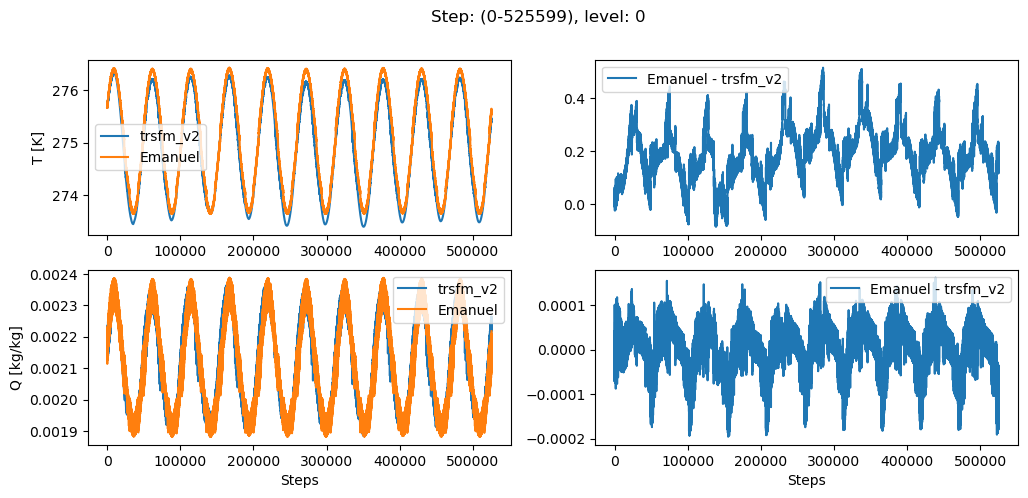

In [8]:
fig = plt.figure(figsize=(12,5))
plt.suptitle(f'Step: (0-{time_idx}), level: {lev_idx}')

ax = fig.add_subplot(2,2,1)
ax.plot(nn_input['air_temperature'][:time_idx].isel(mid_levels=lev_idx).squeeze(), label=f"{model_name}")
ax.plot(physics_input['air_temperature'][:time_idx].isel(mid_levels=lev_idx).squeeze(), label='Emanuel')
ax.set_ylabel('T [K]')
plt.legend()

ax = fig.add_subplot(2,2,2)
ax.plot(physics_input['air_temperature'][:time_idx].isel(mid_levels=lev_idx).squeeze() - nn_input['air_temperature'][:time_idx].isel(mid_levels=lev_idx).squeeze(), label=f'Emanuel - {model_name}')
plt.legend()

ax = fig.add_subplot(2,2,3)
ax.plot(nn_input['specific_humidity'][:time_idx].isel(mid_levels=lev_idx).squeeze(), label=f"{model_name}")
ax.plot(physics_input['specific_humidity'][:time_idx].isel(mid_levels=lev_idx).squeeze(), label='Emanuel')
ax.set_xlabel('Steps')
ax.set_ylabel('Q [kg/kg]')
plt.legend()

ax = fig.add_subplot(2,2,4)
ax.plot(physics_input['specific_humidity'][:time_idx].isel(mid_levels=lev_idx).squeeze() - nn_input['specific_humidity'][:time_idx].isel(mid_levels=lev_idx).squeeze(), label=f'Emanuel - {model_name}')
ax.set_xlabel('Steps')
plt.legend()

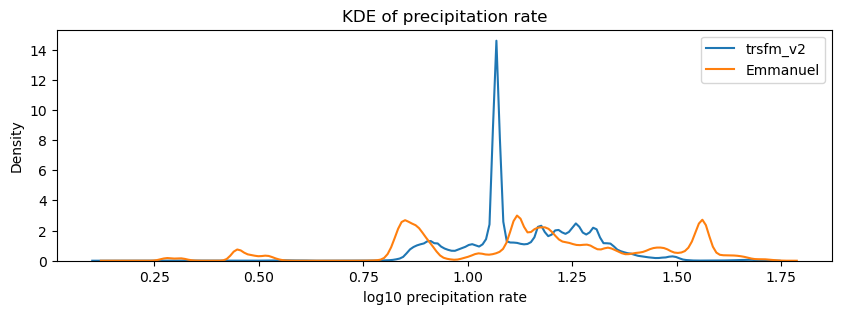

In [9]:
fig = plt.figure(figsize=(10, 3))
ax = plt.subplot(1, 1, 1)
sns.kdeplot(nn_output['convective_precipitation_rate'].values.squeeze(), bw_adjust=0.5, label=f"{model_name}")
sns.kdeplot(physics_output['convective_precipitation_rate'].values.squeeze(), bw_adjust=0.5, label="Emmanuel")
ax.set_xlabel("log10 precipitation rate")
ax.set_ylabel("Density")
ax.set_title("KDE of precipitation rate")
ax.legend()

## convective memory

In [13]:
year = 9
time_idx = 52560 * year - 1
lev_idx = 0
model_name_1 = 'trsfm_v2_Tw_5'
model_name_2 = 'trsfm_v2_Tw_10'
model_name_3 = 'trsfm_v2_Tw_15'
model_name_4 = 'trsfm_v2_Tw_20'
model_name_5 = 'mlp_v2'
model_name_6 = 'lstm'
exp_name_online = '0'

nn_input_1 = xr.open_dataset(online_path + f'/online_input_{model_name_1}_{exp_name_online}.nc')
nn_output_1 = xr.open_dataset(online_path + f'/online_output_{model_name_1}_{exp_name_online}.nc')
nn_input_2 = xr.open_dataset(online_path + f'/online_input_{model_name_2}_{exp_name_online}.nc')
nn_output_2 = xr.open_dataset(online_path + f'/online_output_{model_name_2}_{exp_name_online}.nc')
nn_input_3 = xr.open_dataset(online_path + f'/online_input_{model_name_3}_{exp_name_online}.nc')
nn_output_3 = xr.open_dataset(online_path + f'/online_output_{model_name_3}_{exp_name_online}.nc')
nn_input_4 = xr.open_dataset(online_path + f'/online_input_{model_name_4}_{exp_name_online}.nc')
nn_output_4 = xr.open_dataset(online_path + f'/online_output_{model_name_4}_{exp_name_online}.nc')
nn_input_5 = xr.open_dataset(online_path + f'/online_input_{model_name_5}_{exp_name_online}.nc')
nn_output_5 = xr.open_dataset(online_path + f'/online_output_{model_name_5}_{exp_name_online}.nc')
nn_input_6 = xr.open_dataset(online_path + f'/online_input_{model_name_6}_{exp_name_online}.nc')
nn_output_6 = xr.open_dataset(online_path + f'/online_output_{model_name_6}_{exp_name_online}.nc')
physics_input = xr.open_dataset(online_path + f'/online_input_physics.nc')
physics_output = xr.open_dataset(online_path + f'/online_output_physics.nc')

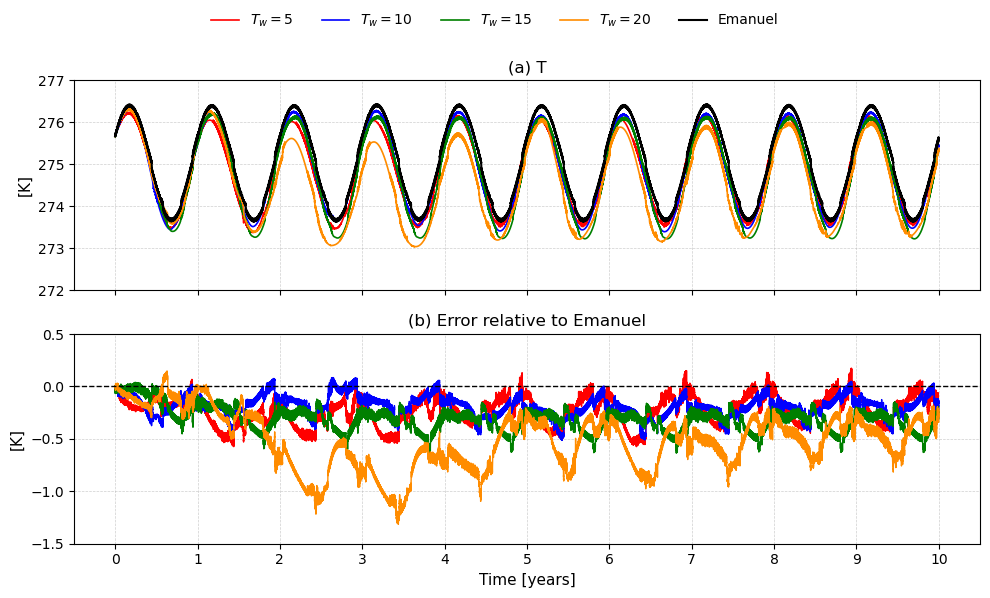

In [4]:
# =========================================================
# paper-quality online simulation plot
# =========================================================

years = np.arange(0, 11)
ticks = years * 52560

# colorblind-friendly palette
colors = {
    "Tw5":  "red",
    "Tw10": "blue",
    "Tw15": "green",
    "Tw20": "darkorange",
    "phys": "black"
}

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# =========================================================
# (a) Temperature evolution
# =========================================================
axs[0].plot(nn_input_1['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
            label=r"$T_w=5$", linewidth=1.2, color=colors["Tw5"])
axs[0].plot(nn_input_2['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
            label=r"$T_w=10$", linewidth=1.2, color=colors["Tw10"])
axs[0].plot(nn_input_3['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
            label=r"$T_w=15$", linewidth=1.2, color=colors["Tw15"])
axs[0].plot(nn_input_4['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
            label=r"$T_w=20$", linewidth=1.2, color=colors["Tw20"])

axs[0].plot(physics_input['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
            label="Emanuel", linewidth=1.5, color=colors["phys"])

axs[0].set_ylabel("[K]", fontsize=11)
axs[0].set_ylim(272, 277)
axs[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
axs[0].set_title("(a) T", fontsize=12)

# =========================================================
# (b) Error relative to Emanuel
# =========================================================
axs[1].plot(
    nn_input_1['air_temperature'].isel(mid_levels=lev_idx).squeeze()
    - physics_input['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
    linewidth=1.0, color=colors["Tw5"], label=r"$T_w=5$"
)

axs[1].plot(
    nn_input_2['air_temperature'].isel(mid_levels=lev_idx).squeeze()
    - physics_input['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
    linewidth=1.0, color=colors["Tw10"], label=r"$T_w=10$"
)

axs[1].plot(
    nn_input_3['air_temperature'].isel(mid_levels=lev_idx).squeeze()
    - physics_input['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
    linewidth=1.0, color=colors["Tw15"], label=r"$T_w=15$"
)

axs[1].plot(
    nn_input_4['air_temperature'].isel(mid_levels=lev_idx).squeeze()
    - physics_input['air_temperature'].isel(mid_levels=lev_idx).squeeze(),
    linewidth=1.0, color=colors["Tw20"], label=r"$T_w=20$"
)

# zero reference line
axs[1].axhline(0, linestyle='--', color='black', linewidth=1)

axs[1].set_ylabel("[K]", fontsize=11)
axs[1].set_ylim(-1.5, 0.5)
axs[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
axs[1].set_title("(b) Error relative to Emanuel", fontsize=12)

# =========================================================
# shared x-axis (years)
# =========================================================
axs[1].set_xticks(ticks)
axs[1].set_xticklabels(years)
axs[1].set_xlabel("Time [years]", fontsize=11)

# =========================================================
# legend (single, clean)
# =========================================================
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=5,
           frameon=False,
           fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    'figs/online_t_time.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Using common length = 525193


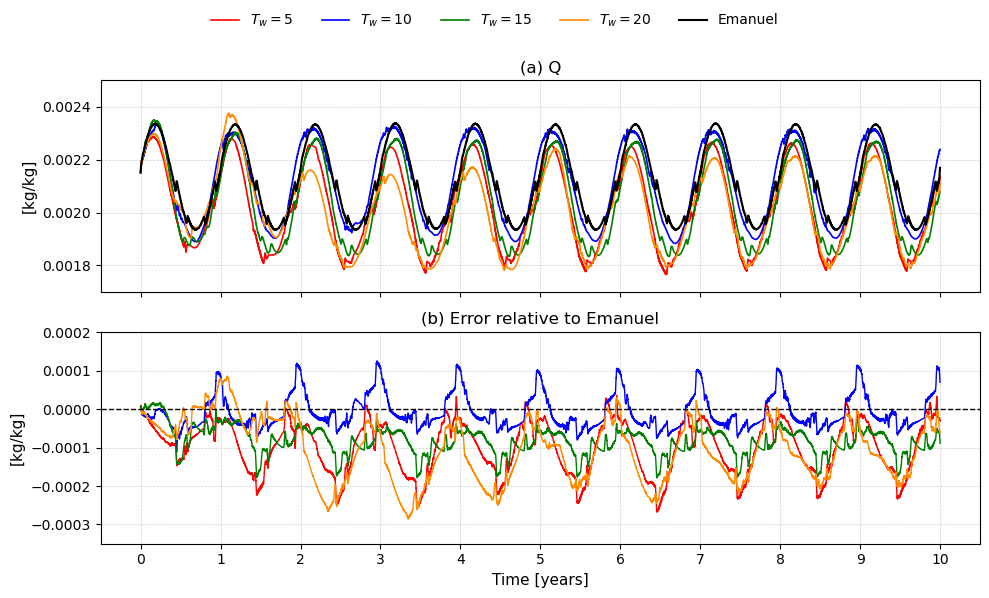

In [5]:
# =========================================================
# smoothing function
# =========================================================
def moving_average(x, window):
    x = np.asarray(x, dtype=np.float64)
    pad_left = window // 2
    pad_right = window - 1 - pad_left

    # edge padding instead of zero padding
    x_padded = np.pad(x, (pad_left, pad_right), mode='edge')

    smoothed = np.convolve(x_padded, np.ones(window) / window, mode='valid')
    return smoothed

def align_to_min_length(*arrays):
    min_len = min(len(np.asarray(a)) for a in arrays)
    return [np.asarray(a)[:min_len] for a in arrays], min_len

# =========================================================
# settings
# =========================================================
window = 720   # 5-day smoothing for 10-min timestep

colors = {
    "Tw5":  "red",
    "Tw10": "blue",
    "Tw15": "green",
    "Tw20": "darkorange",
    "phys": "black"
}

# =========================================================
# extract Q time series
# =========================================================
q_phys = physics_input['specific_humidity'].isel(mid_levels=lev_idx).squeeze().values
q_tw5  = nn_input_1['specific_humidity'].isel(mid_levels=lev_idx).squeeze().values
q_tw10 = nn_input_2['specific_humidity'].isel(mid_levels=lev_idx).squeeze().values
q_tw15 = nn_input_3['specific_humidity'].isel(mid_levels=lev_idx).squeeze().values
q_tw20 = nn_input_4['specific_humidity'].isel(mid_levels=lev_idx).squeeze().values

# =========================================================
# align all series to common length
# =========================================================
(q_phys, q_tw5, q_tw10, q_tw15, q_tw20), n = align_to_min_length(
    q_phys, q_tw5, q_tw10, q_tw15, q_tw20
)

print(f"Using common length = {n}")

# =========================================================
# apply smoothing
# =========================================================
q_phys_s = moving_average(q_phys, window)
q_tw5_s  = moving_average(q_tw5, window)
q_tw10_s = moving_average(q_tw10, window)
q_tw15_s = moving_average(q_tw15, window)
q_tw20_s = moving_average(q_tw20, window)

# smooth error AFTER differencing
err_tw5  = moving_average(q_tw5  - q_phys, window)
err_tw10 = moving_average(q_tw10 - q_phys, window)
err_tw15 = moving_average(q_tw15 - q_phys, window)
err_tw20 = moving_average(q_tw20 - q_phys, window)

# =========================================================
# time axis in years
# =========================================================
time_years = np.linspace(0, 10, n)

# =========================================================
# plot
# =========================================================
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# (a) Q evolution
axs[0].plot(time_years, q_tw5_s,  label=r"$T_w=5$",  linewidth=1.2, color=colors["Tw5"])
axs[0].plot(time_years, q_tw10_s, label=r"$T_w=10$", linewidth=1.2, color=colors["Tw10"])
axs[0].plot(time_years, q_tw15_s, label=r"$T_w=15$", linewidth=1.2, color=colors["Tw15"])
axs[0].plot(time_years, q_tw20_s, label=r"$T_w=20$", linewidth=1.2, color=colors["Tw20"])
axs[0].plot(time_years, q_phys_s, label="Emanuel", linewidth=1.5, color=colors["phys"])

axs[0].set_ylabel("[kg/kg]", fontsize=11)
axs[0].set_ylim(1.7e-3, 2.5e-3)
axs[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
axs[0].set_title("(a) Q", fontsize=12)

# (b) Error relative to Emanuel
axs[1].plot(time_years, err_tw5,  linewidth=1.0, color=colors["Tw5"],  label=r"$T_w=5$")
axs[1].plot(time_years, err_tw10, linewidth=1.0, color=colors["Tw10"], label=r"$T_w=10$")
axs[1].plot(time_years, err_tw15, linewidth=1.0, color=colors["Tw15"], label=r"$T_w=15$")
axs[1].plot(time_years, err_tw20, linewidth=1.0, color=colors["Tw20"], label=r"$T_w=20$")

axs[1].axhline(0, linestyle='--', color='black', linewidth=1)
axs[1].set_ylabel("[kg/kg]", fontsize=11)
axs[1].set_ylim(-3.5e-4, 2e-4)
axs[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
axs[1].set_title("(b) Error relative to Emanuel", fontsize=12)

# x-axis
axs[1].set_xlim(-0.5, 10.5)
axs[1].set_xticks(np.arange(0, 11, 1))
axs[1].set_xlabel("Time [years]", fontsize=11)

# legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('figs/online_q_time.png', dpi=300, bbox_inches='tight')
plt.show()

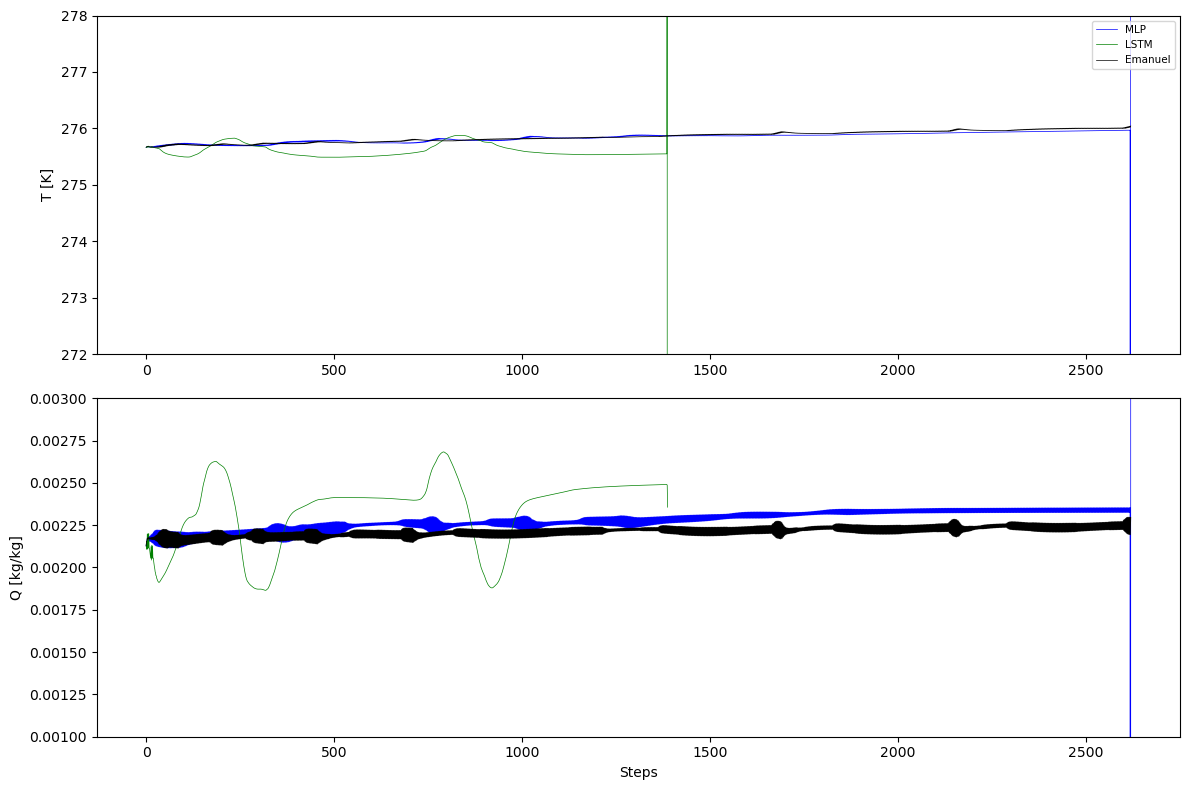

In [4]:
fig = plt.figure(figsize=(12,8))
# plt.suptitle(f'Step: (0-{time_idx}), level: {lev_idx}')

ax = fig.add_subplot(2,1,1)
ax.plot(nn_input_5['air_temperature'].isel(mid_levels=lev_idx).squeeze(), label='MLP', linewidth=0.5, color='blue')
ax.plot(nn_input_6['air_temperature'].isel(mid_levels=lev_idx).squeeze(), label='LSTM', linewidth=0.5, color='green')
ax.plot(physics_input['air_temperature'].isel(time=slice(None, len(nn_input_5['air_temperature']))).isel(mid_levels=lev_idx).squeeze(), label='Emanuel', linewidth=0.5, color='black')
ax.set_ylabel('T [K]')
ax.set_ylim(272, 278)
plt.legend(fontsize=7.5,loc='upper right')

ax = fig.add_subplot(2,1,2)
ax.plot(nn_input_5['specific_humidity'].isel(mid_levels=lev_idx).squeeze(), label='MLP', linewidth=0.5, color='blue')
ax.plot(nn_input_6['specific_humidity'].isel(mid_levels=lev_idx).squeeze(), label='LSTM', linewidth=0.5, color='green')
ax.plot(physics_input['specific_humidity'].isel(time=slice(None, len(nn_input_5['air_temperature']))).isel(mid_levels=lev_idx).squeeze(), label='Emanuel', linewidth=0.5, color='black')
ax.set_ylabel('Q [kg/kg]')
ax.set_ylim(1e-3, 3e-3)

ax.set_xlabel('Steps')

plt.tight_layout()
plt.savefig('figs/crash.png')

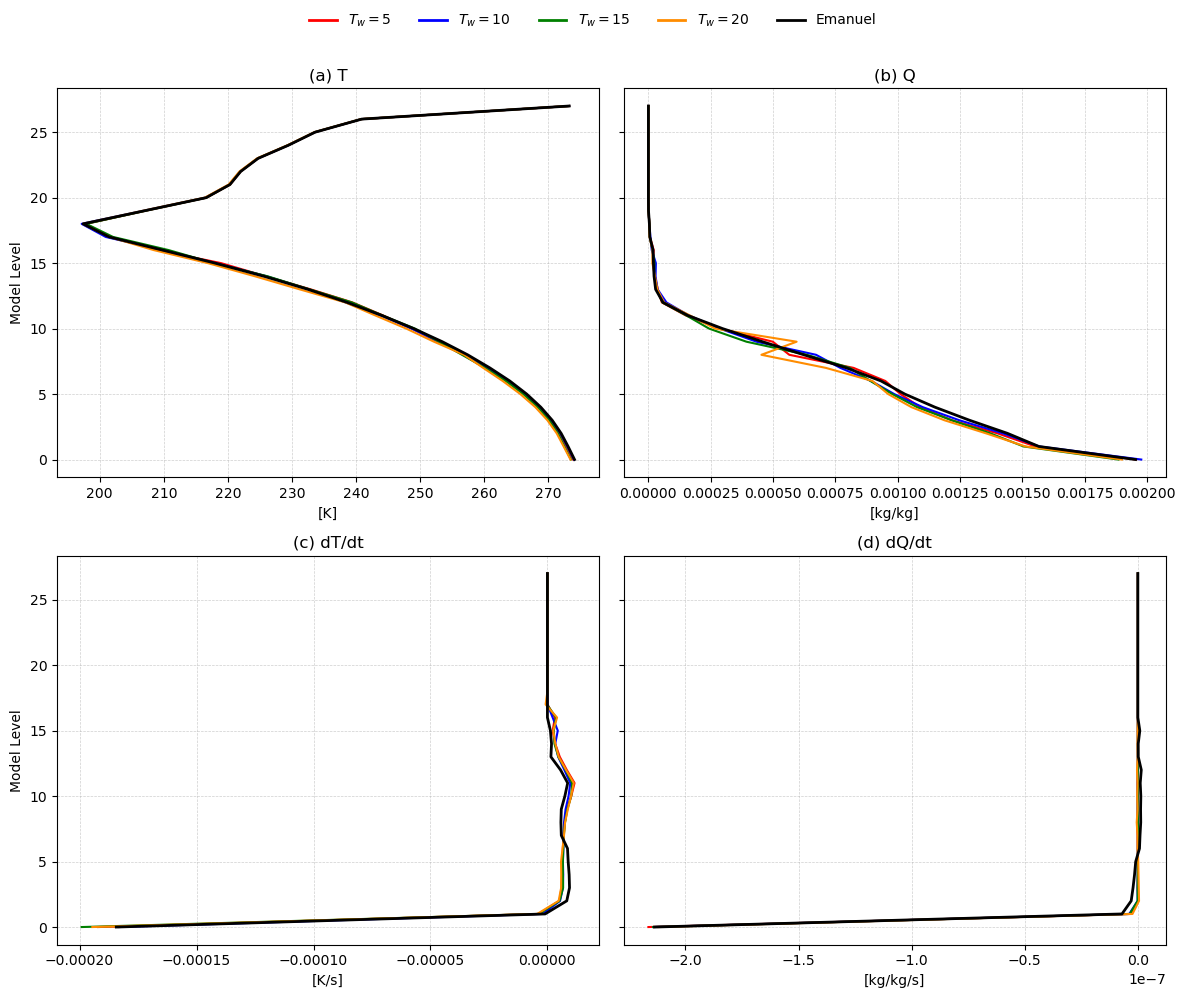

In [10]:
import numpy as np
import matplotlib.pyplot as plt

time_idx = 200000
levels = np.arange(28)

# colorblind-friendly palette
colors = {
    "Tw5":  "red",
    "Tw10": "blue",
    "Tw15": "green",
    "Tw20": "darkorange",
    "phys": "black"
}

fig, axs = plt.subplots(2, 2, figsize=(12, 10), sharey=True)

# =========================================================
# (a) Temperature
# =========================================================
axs[0,0].plot(nn_input_1['air_temperature'].squeeze().isel(time=time_idx), levels, color=colors["Tw5"],  lw=1.5)
axs[0,0].plot(nn_input_2['air_temperature'].squeeze().isel(time=time_idx), levels, color=colors["Tw10"], lw=1.5)
axs[0,0].plot(nn_input_3['air_temperature'].squeeze().isel(time=time_idx), levels, color=colors["Tw15"], lw=1.5)
axs[0,0].plot(nn_input_4['air_temperature'].squeeze().isel(time=time_idx), levels, color=colors["Tw20"], lw=1.5)
axs[0,0].plot(physics_input['air_temperature'].squeeze().isel(time=time_idx), levels, color=colors["phys"], lw=2)

axs[0,0].set_title("(a) T", fontsize=12)
axs[0,0].set_xlabel("[K]")
axs[0,0].set_ylabel("Model Level")

# =========================================================
# (b) Specific humidity
# =========================================================
axs[0,1].plot(nn_input_1['specific_humidity'].squeeze().isel(time=time_idx), levels, color=colors["Tw5"],  lw=1.5)
axs[0,1].plot(nn_input_2['specific_humidity'].squeeze().isel(time=time_idx), levels, color=colors["Tw10"], lw=1.5)
axs[0,1].plot(nn_input_3['specific_humidity'].squeeze().isel(time=time_idx), levels, color=colors["Tw15"], lw=1.5)
axs[0,1].plot(nn_input_4['specific_humidity'].squeeze().isel(time=time_idx), levels, color=colors["Tw20"], lw=1.5)
axs[0,1].plot(physics_input['specific_humidity'].squeeze().isel(time=time_idx), levels, color=colors["phys"], lw=2)

axs[0,1].set_title("(b) Q", fontsize=12)
axs[0,1].set_xlabel("[kg/kg]")

# =========================================================
# (c) dT/dt
# =========================================================
axs[1,0].plot(nn_output_1['air_temperature_tendency_from_NN'].squeeze().isel(time=time_idx), levels, color=colors["Tw5"],  lw=1.5)
axs[1,0].plot(nn_output_2['air_temperature_tendency_from_NN'].squeeze().isel(time=time_idx), levels, color=colors["Tw10"], lw=1.5)
axs[1,0].plot(nn_output_3['air_temperature_tendency_from_NN'].squeeze().isel(time=time_idx), levels, color=colors["Tw15"], lw=1.5)
axs[1,0].plot(nn_output_4['air_temperature_tendency_from_NN'].squeeze().isel(time=time_idx), levels, color=colors["Tw20"], lw=1.5)
axs[1,0].plot(physics_output['air_temperature_tendency_from_EmanuelConvection'].squeeze().isel(time=time_idx), levels, color=colors["phys"], lw=2)

axs[1,0].set_title(r"(c) dT/dt", fontsize=12)
axs[1,0].set_xlabel("[K/s]")
axs[1,0].set_ylabel("Model Level")

# =========================================================
# (d) dQ/dt
# =========================================================
axs[1,1].plot(nn_output_1['specific_humidity_tendency_from_NN'].squeeze().isel(time=time_idx), levels, color=colors["Tw5"],  lw=1.5)
axs[1,1].plot(nn_output_2['specific_humidity_tendency_from_NN'].squeeze().isel(time=time_idx), levels, color=colors["Tw10"], lw=1.5)
axs[1,1].plot(nn_output_3['specific_humidity_tendency_from_NN'].squeeze().isel(time=time_idx), levels, color=colors["Tw15"], lw=1.5)
axs[1,1].plot(nn_output_4['specific_humidity_tendency_from_NN'].squeeze().isel(time=time_idx), levels, color=colors["Tw20"], lw=1.5)
axs[1,1].plot(physics_output['specific_humidity_tendency_from_EmanuelConvection'].squeeze().isel(time=time_idx), levels, color=colors["phys"], lw=2)

axs[1,1].set_title(r"(d) dQ/dt", fontsize=12)
axs[1,1].set_xlabel("[kg/kg/s]")

# =========================================================
# formatting
# =========================================================
for ax in axs.flat:
    ax.invert_yaxis()  # important for vertical profiles
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# single legend
handles = [
    plt.Line2D([0], [0], color=colors["Tw5"],  lw=2),
    plt.Line2D([0], [0], color=colors["Tw10"], lw=2),
    plt.Line2D([0], [0], color=colors["Tw15"], lw=2),
    plt.Line2D([0], [0], color=colors["Tw20"], lw=2),
    plt.Line2D([0], [0], color=colors["phys"], lw=2),
]
labels = [r"$T_w=5$", r"$T_w=10$", r"$T_w=15$", r"$T_w=20$", "Emanuel"]

fig.legend(handles, labels, loc='upper center', ncol=5, frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('figs/online_vert_prof.png', dpi=300, bbox_inches='tight')
plt.show()

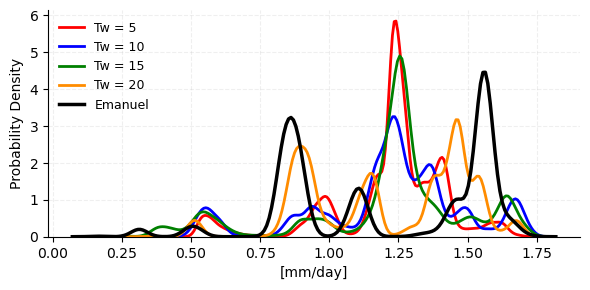

In [25]:
idx = 10000
# ---- extract & clean ----
p1 = nn_output_1['convective_precipitation_rate'][:idx].values.squeeze()
p2 = nn_output_2['convective_precipitation_rate'][:idx].values.squeeze()
p3 = nn_output_3['convective_precipitation_rate'][:idx].values.squeeze()
p4 = nn_output_4['convective_precipitation_rate'][:idx].values.squeeze()
p_phys = physics_output['convective_precipitation_rate'][:idx].values.squeeze()

def clean(x):
    x = x[np.isfinite(x)]
    return x[x >= 0]   # precipitation should be non-negative

p1, p2, p3, p4, p_phys = map(clean, [p1, p2, p3, p4, p_phys])

# ---- plotting ----
plt.figure(figsize=(6, 3))

sns.kdeplot(p1, bw_adjust=0.5, linewidth=2, label='Tw = 5', color='red')
sns.kdeplot(p2, bw_adjust=0.5, linewidth=2, label='Tw = 10', color='blue')
sns.kdeplot(p3, bw_adjust=0.5, linewidth=2, label='Tw = 15', color='green')
sns.kdeplot(p4, bw_adjust=0.5, linewidth=2, label='Tw = 20', color='darkorange')
sns.kdeplot(p_phys, bw_adjust=0.5, linewidth=2.5, label='Emanuel', color='black')

# ---- styling ----
plt.xlabel('[mm/day]')
plt.ylabel('Probability Density')
# plt.title('Distribution of convective precipitation')

# # ---- focus on main distribution (optional but recommended) ----
# # avoids extreme tails dominating the figure
# upper = np.percentile(p_phys, 99.5)
# plt.xlim(0, upper)

# ---- legend ----
plt.legend(frameon=False, fontsize=9)

# ---- aesthetics ----
sns.despine()
plt.grid(alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('figs/online_precip_kde.png', dpi=300)
plt.show()

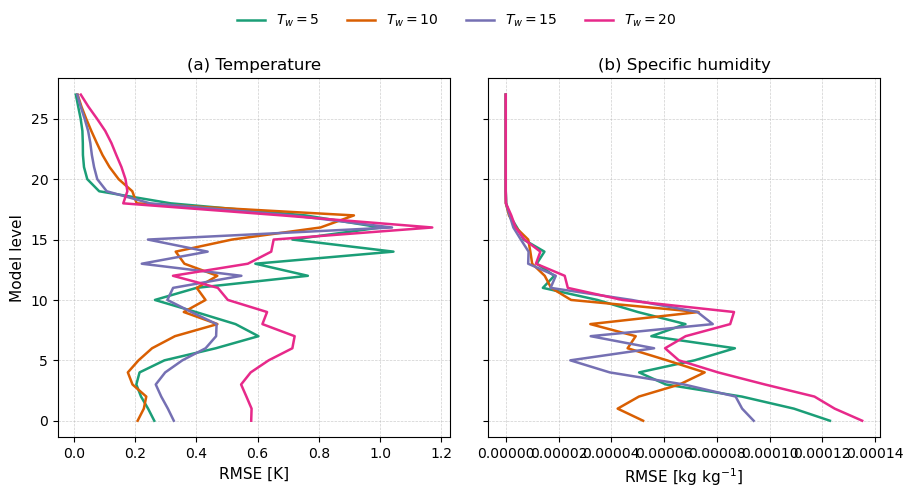

In [15]:
import numpy as np
import matplotlib.pyplot as plt

year = 9
# start_idx = 52560 * (year - 1)
# end_idx   = 52560 * year
start_idx = 0
end_idx   = -1

model_inputs = {
    r"$T_w=5$":  nn_input_1,
    r"$T_w=10$": nn_input_2,
    r"$T_w=15$": nn_input_3,
    r"$T_w=20$": nn_input_4,
}

colors = {
    r"$T_w=5$":  "#1b9e77",
    r"$T_w=10$": "#d95f02",
    r"$T_w=15$": "#7570b3",
    r"$T_w=20$": "#e7298a",
}

def get_time_level_array(ds, var_name, start_idx, end_idx):
    da = ds[var_name].isel(time=slice(start_idx, end_idx))

    vert_dim_candidates = ['mid_levels', 'lev', 'level']
    vert_dim = None
    for d in vert_dim_candidates:
        if d in da.dims:
            vert_dim = d
            break

    if vert_dim is None:
        raise ValueError(f"Could not find vertical dimension in {var_name}. Dims are {da.dims}")

    other_dims = [d for d in da.dims if d not in ['time', vert_dim]]
    if len(other_dims) > 0:
        da = da.mean(dim=other_dims)

    return da

# reference
T_phys = get_time_level_array(physics_input, 'air_temperature', start_idx, end_idx)
Q_phys = get_time_level_array(physics_input, 'specific_humidity', start_idx, end_idx)

vert_dim = [d for d in T_phys.dims if d != 'time'][0]
levels = np.arange(T_phys.sizes[vert_dim])

fig, axs = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

for label, ds in model_inputs.items():
    T_nn = get_time_level_array(ds, 'air_temperature', start_idx, end_idx)
    Q_nn = get_time_level_array(ds, 'specific_humidity', start_idx, end_idx)

    T_rmse = np.sqrt(((T_nn - T_phys) ** 2).mean(dim='time'))
    Q_rmse = np.sqrt(((Q_nn - Q_phys) ** 2).mean(dim='time'))

    axs[0].plot(
        T_rmse.values, levels,
        linewidth=1.8,
        color=colors[label],
        label=label
    )
    axs[1].plot(
        Q_rmse.values, levels,
        linewidth=1.8,
        color=colors[label],
        label=label
    )

# formatting
axs[0].set_title("(a) Temperature", fontsize=12)
axs[1].set_title("(b) Specific humidity", fontsize=12)

axs[0].set_xlabel("RMSE [K]", fontsize=11)
axs[1].set_xlabel(r"RMSE [kg kg$^{-1}$]", fontsize=11)
axs[0].set_ylabel("Model level", fontsize=11)

for ax in axs:
    ax.invert_yaxis()
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    ax.tick_params(labelsize=10)

# optional: use log scale for humidity if differences are subtle
# axs[1].set_xscale('log')

# optional: focus only on bottom 19 levels
# axs[0].set_ylim(18.5, -0.5)
# axs[1].set_ylim(18.5, -0.5)

# shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=4,
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('figs/online_rmse_vert1.png', dpi=300, bbox_inches='tight')
plt.show()

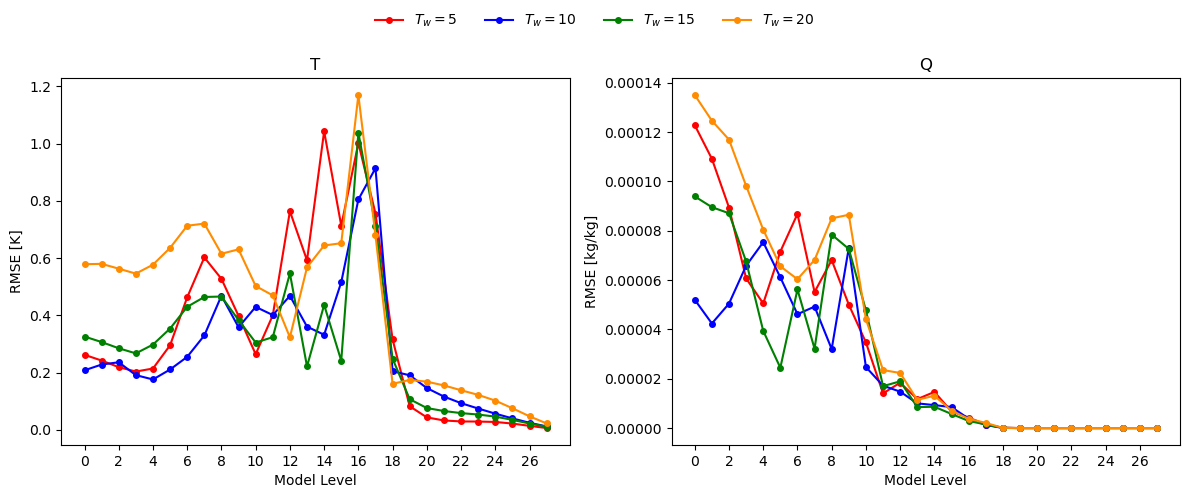

In [20]:
import numpy as np
import matplotlib.pyplot as plt

year = 9
start_idx = 0
end_idx   = -1

model_inputs = {
    r"$T_w=5$":  nn_input_1,
    r"$T_w=10$": nn_input_2,
    r"$T_w=15$": nn_input_3,
    r"$T_w=20$": nn_input_4,
}

colors = {
    r"$T_w=5$":  "red",
    r"$T_w=10$": "blue",
    r"$T_w=15$": "green",
    r"$T_w=20$": "darkorange",
}

def get_time_level_array(ds, var_name, start_idx, end_idx):
    da = ds[var_name].isel(time=slice(start_idx, end_idx))

    vert_dim_candidates = ['mid_levels', 'lev', 'level']
    vert_dim = None
    for d in vert_dim_candidates:
        if d in da.dims:
            vert_dim = d
            break

    if vert_dim is None:
        raise ValueError(f"Could not find vertical dimension in {var_name}. Dims are {da.dims}")

    other_dims = [d for d in da.dims if d not in ['time', vert_dim]]
    if len(other_dims) > 0:
        da = da.mean(dim=other_dims)

    return da

T_phys = get_time_level_array(physics_input, 'air_temperature', start_idx, end_idx)
Q_phys = get_time_level_array(physics_input, 'specific_humidity', start_idx, end_idx)

levels = np.arange(T_phys.sizes[[d for d in T_phys.dims if d != 'time'][0]])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for label, ds in model_inputs.items():
    T_nn = get_time_level_array(ds, 'air_temperature', start_idx, end_idx)
    Q_nn = get_time_level_array(ds, 'specific_humidity', start_idx, end_idx)

    T_rmse = np.sqrt(((T_nn - T_phys) ** 2).mean(dim='time'))
    Q_rmse = np.sqrt(((Q_nn - Q_phys) ** 2).mean(dim='time'))

    axs[0].plot(levels, T_rmse.values, marker='o', linewidth=1.5,
                color=colors[label], label=label, markersize=4)
    axs[1].plot(levels, Q_rmse.values, marker='o', linewidth=1.5,
                color=colors[label], markersize=4)

axs[0].set_title('T')
axs[0].set_xlabel('Model Level')
axs[0].set_ylabel('RMSE [K]')

axs[1].set_title('Q')
axs[1].set_xlabel('Model Level')
axs[1].set_ylabel('RMSE [kg/kg]')

axs[0].set_xticks(levels[::2])
axs[1].set_xticks(levels[::2])

# shared legend (same style as your reference)
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=4,
           frameon=False,
           fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('figs/online_rmse_vert.png', dpi=300, bbox_inches='tight')

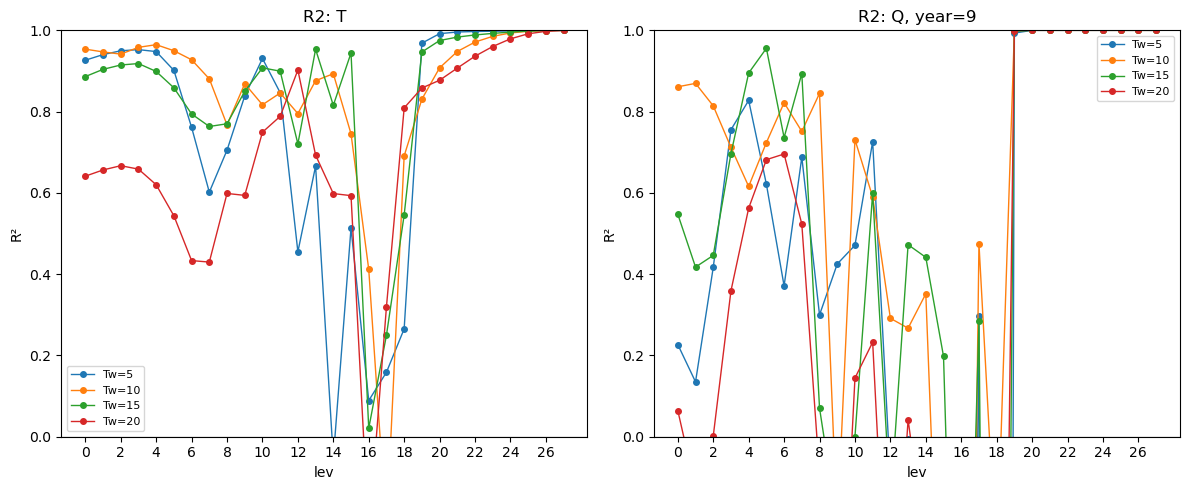

In [31]:
year = 9
# start_idx = 52560 * (year - 1)
# end_idx   = 52560 * year
start_idx = 0
end_idx   = -1

model_inputs = {
    'Tw=5': nn_input_1,
    'Tw=10': nn_input_2,
    'Tw=15': nn_input_3,
    'Tw=20': nn_input_4,
}

def get_time_level_array(ds, var_name, start_idx, end_idx):
    da = ds[var_name].isel(time=slice(start_idx, end_idx))

    vert_dim_candidates = ['mid_levels', 'lev', 'level']
    vert_dim = None
    for d in vert_dim_candidates:
        if d in da.dims:
            vert_dim = d
            break

    if vert_dim is None:
        raise ValueError(f"Could not find vertical dimension in {var_name}. Dims are {da.dims}")

    other_dims = [d for d in da.dims if d not in ['time', vert_dim]]
    if len(other_dims) > 0:
        da = da.mean(dim=other_dims)

    return da


T_phys = get_time_level_array(physics_input, 'air_temperature', start_idx, end_idx)
Q_phys = get_time_level_array(physics_input, 'specific_humidity', start_idx, end_idx)

vert_dim = [d for d in T_phys.dims if d != "time"][0]
levels = np.arange(T_phys.sizes[vert_dim])

fig, axs = plt.subplots(1, 2, figsize=(12,5))

for label, ds in model_inputs.items():

    T_nn = get_time_level_array(ds, 'air_temperature', start_idx, end_idx)
    Q_nn = get_time_level_array(ds, 'specific_humidity', start_idx, end_idx)

    # ---------- R2 computation ----------
    T_res = ((T_nn - T_phys) ** 2).sum(dim="time")
    T_tot = ((T_phys - T_phys.mean(dim="time")) ** 2).sum(dim="time")
    T_r2 = 1 - T_res / T_tot

    Q_res = ((Q_nn - Q_phys) ** 2).sum(dim="time")
    Q_tot = ((Q_phys - Q_phys.mean(dim="time")) ** 2).sum(dim="time")
    Q_r2 = 1 - Q_res / Q_tot

    axs[0].plot(levels, T_r2.values, marker='o', linewidth=1, label=label, markersize=4)
    axs[1].plot(levels, Q_r2.values, marker='o', linewidth=1, label=label, markersize=4)


axs[0].set_title(f'R2: T')
axs[0].set_xlabel('lev')
axs[0].set_ylabel('R²')

axs[1].set_title(f'R2: Q')
axs[1].set_xlabel('lev')
axs[1].set_ylabel('R²')

axs[0].set_xticks(levels[::2])
axs[1].set_xticks(levels[::2])

axs[0].axhline(0, color='black', linewidth=0.8)
axs[1].axhline(0, color='black', linewidth=0.8)

axs[0].legend(fontsize=8)
axs[1].legend(fontsize=8)

axs[0].set_ylim(0,1)
axs[1].set_ylim(0,1)

plt.tight_layout()
plt.savefig('figs/online_r2_vert.png')

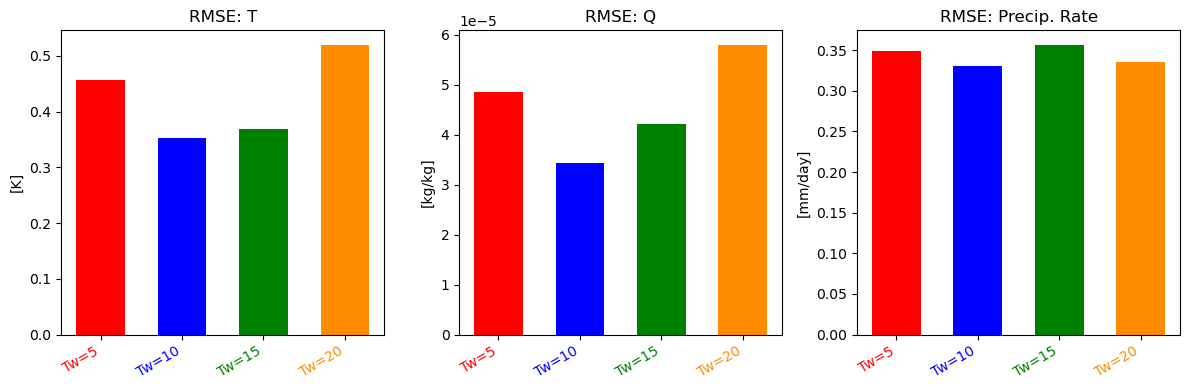


RMSE summary (year 9)
Model               T            Q       Precip
Tw=5       4.5574e-01   4.8650e-05   3.4842e-01
Tw=10      3.5218e-01   3.4402e-05   3.3011e-01
Tw=15      3.6876e-01   4.2220e-05   3.5654e-01
Tw=20      5.1970e-01   5.8029e-05   3.3533e-01


In [14]:
year = 9
start_idx = 0
end_idx   = -1

model_inputs = {
    'Tw=5':  nn_input_1,
    'Tw=10': nn_input_2,
    'Tw=15': nn_input_3,
    'Tw=20': nn_input_4,
}

model_outputs = {
    'Tw=5':  nn_output_1,
    'Tw=10': nn_output_2,
    'Tw=15': nn_output_3,
    'Tw=20': nn_output_4,
}

def get_time_level_array(ds, var_name, start_idx, end_idx):
    da = ds[var_name].isel(time=slice(start_idx, end_idx))

    vert_dim_candidates = ['mid_levels', 'lev', 'level']
    vert_dim = None

    for d in vert_dim_candidates:
        if d in da.dims:
            vert_dim = d
            break

    if vert_dim is None:
        raise ValueError(f"Vertical dimension not found in {var_name}. Dims: {da.dims}")

    other_dims = [d for d in da.dims if d not in ['time', vert_dim]]
    if len(other_dims) > 0:
        da = da.mean(dim=other_dims)

    return da

def get_time_array(ds, var_name, start_idx, end_idx):
    da = ds[var_name].isel(time=slice(start_idx, end_idx))

    other_dims = [d for d in da.dims if d != 'time']
    if len(other_dims) > 0:
        da = da.mean(dim=other_dims)

    return da

# -------------------------
# reference (Emanuel/physics)
# -------------------------
T_phys = get_time_level_array(
    physics_input, 'air_temperature', start_idx, end_idx
)
Q_phys = get_time_level_array(
    physics_input, 'specific_humidity', start_idx, end_idx
)
P_phys = get_time_array(
    physics_output, 'convective_precipitation_rate', start_idx, end_idx
)

results = []

for label in model_inputs.keys():
    ds_in  = model_inputs[label]
    ds_out = model_outputs[label]

    T_nn = get_time_level_array(ds_in, 'air_temperature', start_idx, end_idx)
    Q_nn = get_time_level_array(ds_in, 'specific_humidity', start_idx, end_idx)
    P_nn = get_time_array(ds_out, 'convective_precipitation_rate', start_idx, end_idx)

    # RMSE
    T_rmse = float(np.sqrt(((T_nn - T_phys) ** 2).mean()).values)
    Q_rmse = float(np.sqrt(((Q_nn - Q_phys) ** 2).mean()).values)
    P_rmse = float(np.sqrt(((P_nn - P_phys) ** 2).mean()).values)

    results.append((label, T_rmse, Q_rmse, P_rmse))

# -------------------------
# convert to arrays
# -------------------------
labels = [r[0] for r in results]
T_vals = [r[1] for r in results]
Q_vals = [r[2] for r in results]
P_vals = [r[3] for r in results]

# -------------------------
# colors for models
# -------------------------
model_colors = {
    'Tw=5':  'red',
    'Tw=10': 'blue',
    'Tw=15': 'green',
    'Tw=20': 'darkorange',
}

x = np.arange(len(labels))
width = 0.6

fig, axs = plt.subplots(1, 3, figsize=(12,4))

# -------------------------
# Temperature
# -------------------------
axs[0].bar(
    x,
    T_vals,
    width=width,
    color=[model_colors[l] for l in labels]
)

axs[0].set_xticks(x)
axs[0].set_xticklabels(labels)
axs[0].set_title(f'RMSE: T')
axs[0].set_ylabel('[K]')

# -------------------------
# Humidity
# -------------------------
axs[1].bar(
    x,
    Q_vals,
    width=width,
    color=[model_colors[l] for l in labels]
)

axs[1].set_xticks(x)
axs[1].set_xticklabels(labels)
axs[1].set_title(f'RMSE: Q')
axs[1].set_ylabel('[kg/kg]')

# -------------------------
# Precipitation
# -------------------------
axs[2].bar(
    x,
    P_vals,
    width=width,
    color=[model_colors[l] for l in labels]
)

axs[2].set_xticks(x)
axs[2].set_xticklabels(labels)
axs[2].set_title(f'RMSE: Precip. Rate')
axs[2].set_ylabel('[mm/day]')

# -------------------------
# color tick labels
# -------------------------
for ax in axs:
    for tick, label in zip(ax.get_xticklabels(), labels):
        tick.set_color(model_colors[label])
        tick.set_rotation(30)
        tick.set_ha('right')

plt.tight_layout()
plt.savefig('figs/online_rmse_all.png')
plt.show()

# -------------------------
# summary print
# -------------------------
print(f"\nRMSE summary (year {year})")
print(f"{'Model':8s} {'T':>12s} {'Q':>12s} {'Precip':>12s}")
for label, T_rmse, Q_rmse, P_rmse in results:
    print(f"{label:8s} {T_rmse:12.4e} {Q_rmse:12.4e} {P_rmse:12.4e}")

# rad-single-col

In [ ]:
# physics=xr.open_dataset(f'/home/wang.shuoc/climt/{exp_folder_name}/{exp_name}_online_physics.nc')
nn=xr.open_dataset(f'{exp_folder_name}_{exp_name}_online_nn.nc')
time_idx = 30000
lev_idx = 0

fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(1,2,1)
ax.plot(nn['air_temperature'].isel(time=time_idx).squeeze(),np.arange(28), label='NN')
# ax.imshow(nn['air_temperature'].isel(time=time_idx, mid_levels=lev_idx), label='NN')
ax.set_title('T')
ax.set_xlabel('[K]')
ax.set_ylabel('lev')
plt.legend()

ax = fig.add_subplot(1,2,2)
# ax.plot(physics['air_temperature_tendency_from_EmanuelConvection'].isel(time=time_idx).squeeze().values,np.arange(28), label='Emmanuel')
plot=ax.plot(nn['air_temperature_tendency_from_NN'].isel(time=time_idx).squeeze(),np.arange(28), label='NN')
ax.set_title('dT/dt from Longwave')
ax.set_xlabel('[K/day]')
plt.legend()

# rad-multi-col

In [ ]:
# physics=xr.open_dataset(f'/home/wang.shuoc/climt/{exp_folder_name}/{exp_name}_online_physics.nc')
nn=xr.open_dataset(f'/home/wang.shuoc/climt/{exp_folder_name}/{exp_name}_online_nn.nc')
time_idx = 50
lev_idx = 15

fig = plt.figure(figsize=(12,3))
# ax = fig.add_subplot(1,2,1)
# # ax.plot(physics['air_temperature'].isel(time=time_idx).squeeze(),np.arange(28), label='Emmanuel')
# ax.imshow(nn['air_temperature'].isel(time=time_idx, mid_levels=lev_idx), label='NN')
# ax.set_title('T')
# ax.set_xlabel('[K]')
# ax.set_ylabel(f'lev = {lev_idx}')
# # plt.legend()

ax = fig.add_subplot(1,2,2)
# ax.plot(physics['air_temperature_tendency_from_EmanuelConvection'].isel(time=time_idx).squeeze().values,np.arange(28), label='Emmanuel')
plot=ax.imshow(nn['air_temperature_tendency_from_NN'].isel(time=time_idx, mid_levels=lev_idx), label='NN')
ax.set_title('dT/dt')
cbar = fig.colorbar(plot, ax=ax)
cbar.set_label('[K/day]')
# ax.set_xlim(left=-5e-5)
# plt.legend()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
# average over longitude
T_nn = nn['air_temperature'].isel(time=time_idx).mean(dim='lon')
# identify vertical dim (safe)
zdim = [d for d in T_nn.dims if d not in ('lat', 'time')][0]
# build coordinates
lat = T_nn['lat']
z   = T_nn[zdim]
# contour plot
cf = ax.contourf(lat,z,T_nn.transpose(zdim, 'lat'),levels=21,cmap='viridis')
# labels
ax.set_title('NN Air Temperature')
ax.set_xlabel('Latitude')
ax.set_ylabel(zdim)
# colorbar
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('[K]')